In [ ]:
from google.colab import files
uploaded = files.upload()

Saving realistic_kraljic_dataset.csv to realistic_kraljic_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("realistic_kraljic_dataset.csv")
df.head()

,Product_ID,Product_Name,Supplier_Region,Lead_Time_Days,Order_Volume_Units,Cost_per_Unit,Supply_Risk_Score,Profit_Impact_Score,Environmental_Impact,Single_Source_Risk,Kraljic_Category
0,P001,Semiconductors,South America,81,171,255.03,5,5,4,Yes,Strategic
1,P002,Semiconductors,South America,8,763,380.33,5,4,4,Yes,Strategic
2,P003,Pharma APIs,Asia,65,413,385.24,4,5,5,Yes,Strategic
3,P004,Semiconductors,South America,70,882,287.64,5,5,5,Yes,Strategic
4,P005,Lithium Batteries,Asia,15,120,382.26,4,4,4,Yes,Strategic


In [ ]:
from sklearn.model_selection import train_test_split

y = df['Kraljic_Category']


X = df.drop(columns=['Product_ID', 'Product_Name', 'Kraljic_Category'])

X = pd.get_dummies(X, columns=['Supplier_Region', 'Single_Source_Risk'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (800, 12)
X_test shape: (200, 12)
y_train shape: (800,)
y_test shape: (200,)


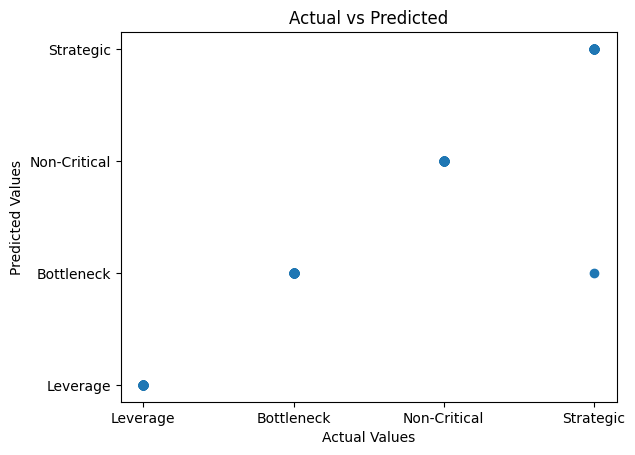

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.feature_importances_
}).sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
2,Cost_per_Unit,0.217599
1,Order_Volume_Units,0.199982
4,Profit_Impact_Score,0.174492
5,Environmental_Impact,0.166546
8,Supplier_Region_Global,0.123869
7,Supplier_Region_Europe,0.038044
3,Supply_Risk_Score,0.024407
11,Single_Source_Risk_Yes,0.017746
10,Supplier_Region_South America,0.012412
9,Supplier_Region_North America,0.010278


In [ ]:
y_pred = model.predict(X_test)
print(y_pred)


['Leverage' 'Leverage' 'Leverage' 'Leverage' 'Bottleneck' 'Leverage'
 'Leverage' 'Leverage' 'Non-Critical' 'Strategic' 'Non-Critical'
 'Strategic' 'Leverage' 'Non-Critical' 'Non-Critical' 'Non-Critical'
 'Bottleneck' 'Non-Critical' 'Non-Critical' 'Bottleneck' 'Leverage'
 'Strategic' 'Bottleneck' 'Leverage' 'Strategic' 'Strategic' 'Strategic'
 'Non-Critical' 'Non-Critical' 'Non-Critical' 'Bottleneck' 'Strategic'
 'Leverage' 'Bottleneck' 'Bottleneck' 'Strategic' 'Leverage' 'Leverage'
 'Non-Critical' 'Strategic' 'Bottleneck' 'Strategic' 'Bottleneck'
 'Non-Critical' 'Bottleneck' 'Bottleneck' 'Non-Critical' 'Leverage'
 'Bottleneck' 'Non-Critical' 'Leverage' 'Non-Critical' 'Bottleneck'
 'Leverage' 'Strategic' 'Strategic' 'Leverage' 'Strategic' 'Strategic'
 'Non-Critical' 'Bottleneck' 'Strategic' 'Leverage' 'Strategic' 'Leverage'
 'Leverage' 'Leverage' 'Non-Critical' 'Strategic' 'Leverage' 'Strategic'
 'Bottleneck' 'Leverage' 'Leverage' 'Bottleneck' 'Bottleneck' 'Leverage'
 'Strategic' 'Lever

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_train, and transform y_test
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

model = LinearRegression()
model.fit(X_train, y_train_encoded)

LinearRegression()

In [ ]:
# Example:
# Assume 'Profit_Impact_Score' is target
# and rest numeric columns are features

X = df.drop(columns=['Profit_Impact_Score'])
y = df['Profit_Impact_Score']
print(X)

    Product_ID       Product_Name Supplier_Region  Lead_Time_Days  \
0         P001     Semiconductors   South America              81   
1         P002     Semiconductors   South America               8   
2         P003        Pharma APIs            Asia              65   
3         P004     Semiconductors   South America              70   
4         P005  Lithium Batteries            Asia              15   
..         ...                ...             ...             ...   
995       P996        Printer Ink          Global              19   
996       P997  Cleaning Supplies          Global              21   
997       P998           Uniforms          Global              70   
998       P999        Printer Ink          Global              44   
999      P1000  Cleaning Supplies          Global              76   

     Order_Volume_Units  Cost_per_Unit  Supply_Risk_Score  \
0                   171         255.03                  5   
1                   763         380.33           

In [ ]:
pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)


{'whiskers': [<matplotlib.lines.Line2D at 0x78d4b7003710>,
 'caps': [<matplotlib.lines.Line2D at 0x78d4b4f2c950>,
 'boxes': [<matplotlib.lines.Line2D at 0x78d4b52a00e0>],
 'medians': [<matplotlib.lines.Line2D at 0x78d4b52ef8f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x78d4b52ef920>],
 'means': []}

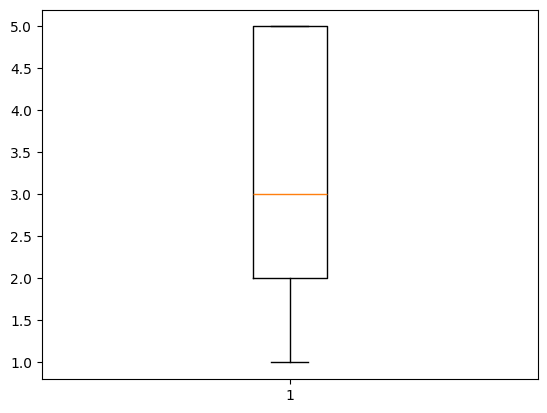